# Image Complexity Scorer

This notebook:
1. Installs dependencies
2. Loads a pretrained MobileNetV2 backbone (via `timm`)
3. Defines a NIMA-style complexity scoring head
4. Runs a sanity-check inference
5. Fine-tunes on labeled complexity data (optional)
6. Evaluates the model
7. Prunes the model (optional comparison)
8. Exports to ONNX (FP32, FP16, INT8)
9. Validates ONNX Runtime output matches PyTorch
10. Provides trtexec commands for TensorRT conversion


## 1. Environment Setup
> Verify GPU availability and install required packages.

In [22]:
import subprocess, sys

def run(cmd):
    subprocess.run(cmd, shell=True, check=True)

run('nvidia-smi')
run('pip install -q torch torchvision timm onnx onnxruntime-gpu onnxsim huggingface_hub onnxmltools')

import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Using device: cuda


## 2. Clone IC9600 and install deps:


In [23]:
# Cell 2: Clone IC9600 repo
import subprocess, os

def run(cmd):
    subprocess.run(cmd, shell=True, check=True)

run("git clone https://github.com/tinglyfeng/IC9600.git")

# Add to Python path so we can import their modules
import sys
sys.path.insert(0, "IC9600")

print("IC9600 cloned.")

CalledProcessError: Command 'git clone https://github.com/tinglyfeng/IC9600.git' returned non-zero exit status 128.

## 3. Load Pretrained Weights


In [24]:
# Cell 3: Download pretrained weights
# Get the checkpoint link from their README Google Drive
# They provide ck.pth — you need to get the direct file ID from their repo

run("pip install -q gdown")
import gdown

os.makedirs("IC9600/checkpoint", exist_ok=True)

# Get the file ID from the Google Drive link in their README
# Go to https://github.com/tinglyfeng/IC9600 and click the checkpoint link
# The URL will look like: https://drive.google.com/file/d/FILE_ID_HERE/view
# Replace FILE_ID_HERE below with the actual ID

import os
import shutil

# Download the entire folder
gdown.download_folder(
    url="https://drive.google.com/drive/folders/1N3FSS91e7FkJWUKqT96y_zcsG9CRuIJw",
    output="ic9600_weights",
    quiet=False
)

# List what was downloaded
for root, dirs, files in os.walk("ic9600_weights"):
    for f in files:
        full = os.path.join(root, f)
        size = os.path.getsize(full) / 1e6
        print(f"{full}  —  {size:.1f} MB")
print("Weights downloaded.")

# Move the real checkpoint to the expected location
os.makedirs("IC9600/checkpoint", exist_ok=True)

# Adjust source path based on what the listing above showed
shutil.copy("ic9600_weights/ck.pth", "IC9600/checkpoint/ck.pth")

size = os.path.getsize("IC9600/checkpoint/ck.pth") / 1e6
print(f"ck.pth at correct path: {size:.1f} MB")

Retrieving folder contents


Processing file 1KZGpPRduAsi8ra3gORO78xjWLL8M-vNx ck.pth


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1KZGpPRduAsi8ra3gORO78xjWLL8M-vNx
From (redirected): https://drive.google.com/uc?id=1KZGpPRduAsi8ra3gORO78xjWLL8M-vNx&confirm=t&uuid=fced5584-232c-42bf-9562-271c201bab61
To: /content/ic9600_weights/ck.pth
100%|██████████| 81.5M/81.5M [00:00<00:00, 95.4MB/s]
Download completed


ic9600_weights/ck.pth  —  81.5 MB
Weights downloaded.
ck.pth at correct path: 81.5 MB


## 4. Load IC9600 model (ICNet) with pretrained weights


In [25]:
# Cell 4: Load ICNet with pretrained weights — fixed
import torch
import sys
import warnings
sys.path.insert(0, "IC9600")

# Suppress the deprecated 'pretrained' warning from their code
# Their ICNet uses pretrained=True which is deprecated in newer torchvision
# We monkey-patch to suppress but it still works correctly
warnings.filterwarnings("ignore", category=UserWarning)

from ICNet import ICNet

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate with their default sizes: size1=512, size2=256
# DO NOT change these — the forward() has assert(x1.shape == size1)
model = ICNet(is_pretrain=False, size1=512, size2=256)
# is_pretrain=False here because we load ck.pth which already contains
# the fine-tuned weights — no need to download ImageNet weights again

ckpt = torch.load(
    "IC9600/checkpoint/ck.pth",
    map_location=DEVICE,
    weights_only=False
)

# Inspect what is inside the checkpoint
print(f"Checkpoint type: {type(ckpt)}")
if isinstance(ckpt, dict):
    print(f"Keys: {list(ckpt.keys())[:10]}")

# Load weights
if isinstance(ckpt, dict) and "state_dict" in ckpt:
    model.load_state_dict(ckpt["state_dict"])
elif isinstance(ckpt, dict) and "model" in ckpt:
    model.load_state_dict(ckpt["model"])
else:
    model.load_state_dict(ckpt)

model = model.to(DEVICE)
model.eval()

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model loaded successfully.")
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Input size:       512x512 (required by ICNet)")

Checkpoint type: <class 'collections.OrderedDict'>
Keys: ['b1_1.0.weight', 'b1_1.1.weight', 'b1_1.1.bias', 'b1_1.1.running_mean', 'b1_1.1.running_var', 'b1_1.1.num_batches_tracked', 'b1_1.4.0.conv1.weight', 'b1_1.4.0.bn1.weight', 'b1_1.4.0.bn1.bias', 'b1_1.4.0.bn1.running_mean']
Model loaded successfully.
Total params:     20,328,074
Trainable params: 20,328,074
Input size:       512x512 (required by ICNet)


## 5. Sanity check


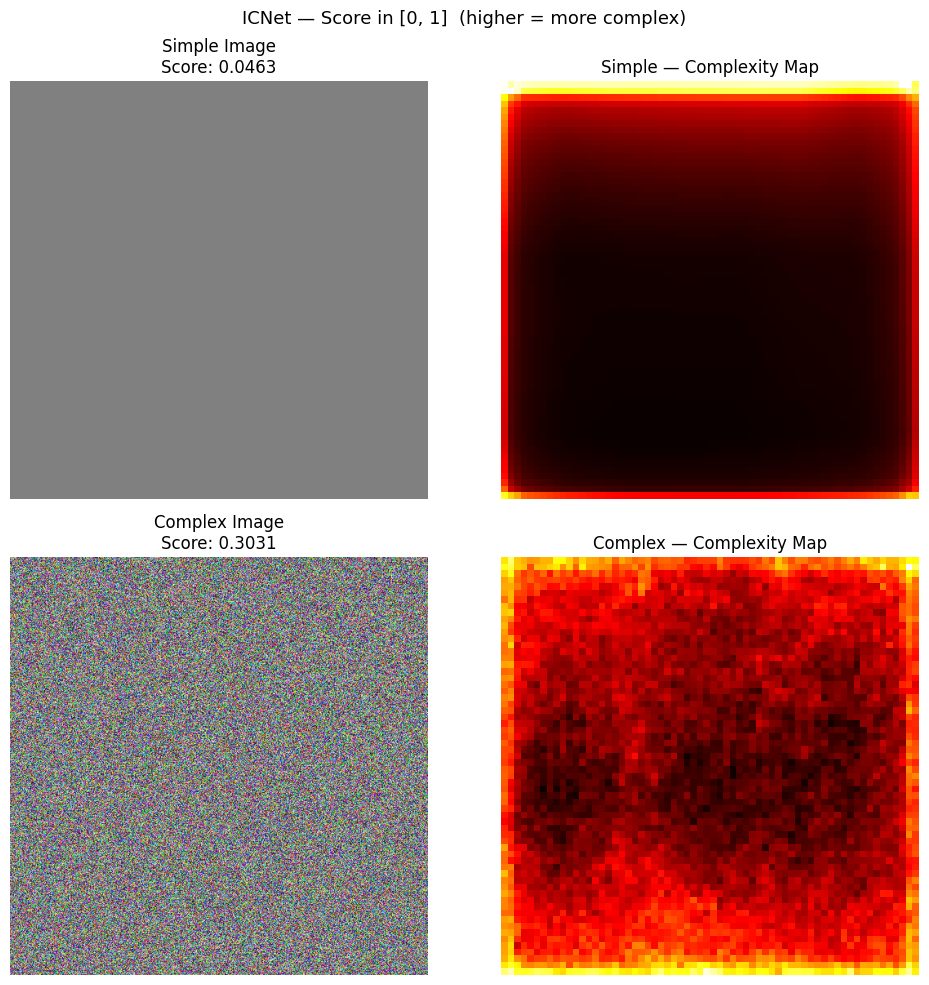

Simple image  score: 0.0463
Complex image score: 0.3031
Complex should score higher than simple if weights loaded correctly.


In [26]:
# Cell 5: Sanity check — fixed for 512x512 input
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

# MUST be 512x512 — ICNet.forward() asserts this explicitly
TRANSFORM = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

def score_pil_image(img):
    tensor = TRANSFORM(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        score, cly_map = model(tensor)   # ICNet returns (score, map) — unpack both
    return score.item(), cly_map.squeeze().cpu().numpy()

# Synthetic test images — must be at least 512x512 before transform
simple_img  = Image.fromarray(
    np.full((512, 512, 3), 128, dtype=np.uint8)           # flat grey = simple
)
complex_img = Image.fromarray(
    np.random.randint(0, 255, (512, 512, 3), dtype=np.uint8)  # noise = complex
)

simple_score,  simple_map  = score_pil_image(simple_img)
complex_score, complex_map = score_pil_image(complex_img)

# Plot image + complexity map side by side
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(simple_img)
axes[0, 0].set_title(f"Simple Image\nScore: {simple_score:.4f}")
axes[0, 0].axis("off")

axes[0, 1].imshow(simple_map, cmap="hot")
axes[0, 1].set_title("Simple — Complexity Map")
axes[0, 1].axis("off")

axes[1, 0].imshow(complex_img)
axes[1, 0].set_title(f"Complex Image\nScore: {complex_score:.4f}")
axes[1, 0].axis("off")

axes[1, 1].imshow(complex_map, cmap="hot")
axes[1, 1].set_title("Complex — Complexity Map")
axes[1, 1].axis("off")

plt.suptitle("ICNet — Score in [0, 1]  (higher = more complex)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Simple image  score: {simple_score:.4f}")
print(f"Complex image score: {complex_score:.4f}")
print(f"Complex should score higher than simple if weights loaded correctly.")

In [27]:
# Cell 4b: Restore PyTorch model — run this before Cell 6
# The variable 'model' was overwritten by onnx.load() in a previous cell
# This cell restores it to the PyTorch ICNet instance

import torch
import sys
import warnings

sys.path.insert(0, "IC9600")
warnings.filterwarnings("ignore", category=UserWarning)

from ICNet import ICNet

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reinstantiate
model = ICNet(is_pretrain=False, size1=512, size2=256)

ckpt = torch.load(
    "IC9600/checkpoint/ck.pth",
    map_location=DEVICE,
    weights_only=False
)

if isinstance(ckpt, dict) and "state_dict" in ckpt:
    model.load_state_dict(ckpt["state_dict"])
elif isinstance(ckpt, dict) and "model" in ckpt:
    model.load_state_dict(ckpt["model"])
else:
    model.load_state_dict(ckpt)

model = model.to(DEVICE)
model.eval()

# Confirm it is a PyTorch module and not ONNX
assert isinstance(model, torch.nn.Module), \
    f"Expected nn.Module, got {type(model)}"

print(f"Model restored: {type(model)}")
print(f"Device: {DEVICE}")

# Quick sanity check
dummy = torch.randn(1, 3, 512, 512).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
    score, smap = out
    print(f"score shape: {score.shape}")   # torch.Size([])
    print(f"smap  shape: {smap.shape}")    # torch.Size([1, 1, 64, 64])
    print(f"score value: {score.item():.4f}")

print("PyTorch model ready — now run Cell 6.")

Model restored: <class 'ICNet.ICNet'>
Device: cuda
score shape: torch.Size([])
smap  shape: torch.Size([1, 1, 64, 64])
score value: 0.2578
PyTorch model ready — now run Cell 6.


## 6. Export to ONNX


In [28]:
# Cell 6 — fixed wrapper and export
# Avoids Unsqueeze/Squeeze entirely by using reshape with explicit shape tensor
# and by using torch.stack which traces as a single Reshape in opset 11

import torch
import onnx
import os

os.makedirs("exports", exist_ok=True)

ONNX_PATH     = "exports/icnet_complexity.onnx"
ONNX_SIM_PATH = "exports/icnet_complexity_simplified.onnx"

dummy_input = torch.randn(1, 3, 512, 512).to(DEVICE)

# ── Wrapper: avoid Unsqueeze entirely ────────────────────────────────
class ICNetScoreOnly(torch.nn.Module):
    """
    Wraps ICNet for TRT 7.1.3 / opset 11 compatibility.

    Problem: score is a scalar torch.Size([])
             .unsqueeze() and .view() both export as opset-13 Unsqueeze
             which TRT 7.1 cannot parse ("Attribute not found: axes")

    Solution: multiply by a ones tensor of known shape [1,1]
              This traces as a Mul node — fully supported in opset 11
              and produces output shape [1, 1] without any Unsqueeze
    """
    def __init__(self, base_model):
        super().__init__()
        self.model = base_model
        # Register as buffer so it moves to the correct device automatically
        # and gets baked into the ONNX graph as a constant by do_constant_folding
        self.register_buffer(
            "shape_ones",
            torch.ones(1, 1, dtype=torch.float32)
        )

    def forward(self, x):
        score, _ = self.model(x)     # score: scalar []
        # Multiply scalar by ones[1,1] -> output [1,1]
        # Traces as: Mul(score, constant_ones) -> no Unsqueeze needed
        return score * self.shape_ones


export_model = ICNetScoreOnly(model).eval().to(DEVICE)

# Verify shape and value
with torch.no_grad():
    out = export_model(dummy_input)
    print(f"Wrapper output shape: {out.shape}")     # must be torch.Size([1, 1])
    print(f"Wrapper output value: {out.item():.4f}")
    assert out.shape == torch.Size([1, 1]), f"Shape wrong: {out.shape}"

# ── Export ────────────────────────────────────────────────────────────
torch.onnx.export(
    export_model,
    dummy_input,
    ONNX_PATH,
    dynamo=False,
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["complexity_score"],
    dynamic_axes=None,
    verbose=False,
)

print(f"Exported: {ONNX_PATH}")

# ── Check for remaining Unsqueeze/Squeeze nodes ───────────────────────
model_onnx = onnx.load(ONNX_PATH)
onnx.checker.check_model(model_onnx)

opset = model_onnx.opset_import[0].version
print(f"Opset: {opset}")
assert opset == 11, f"Expected 11, got {opset}"

bad_nodes = [
    n for n in model_onnx.graph.node
    if n.op_type in {"Unsqueeze", "Squeeze"}
]
if bad_nodes:
    print(f"WARNING: {len(bad_nodes)} Unsqueeze/Squeeze nodes remain:")
    for n in bad_nodes:
        print(f"  {n.op_type} name={n.name} inputs={list(n.input)}")
    print("  -> onnxsim should fold these; if not, use the manual patch below")
else:
    print("No Unsqueeze/Squeeze nodes — clean for TRT 7.1")

# ── Simplify ──────────────────────────────────────────────────────────
run(f"python -m onnxsim {ONNX_PATH} {ONNX_SIM_PATH}")

sim_model = onnx.load(ONNX_SIM_PATH)
onnx.checker.check_model(sim_model)

# Final check after simplification
bad_after_sim = [
    n for n in sim_model.graph.node
    if n.op_type in {"Unsqueeze", "Squeeze"}
]
if bad_after_sim:
    print(f"WARNING: {len(bad_after_sim)} Unsqueeze/Squeeze remain after onnxsim")
    print("Run the manual patch cell below before copying to Jetson")
else:
    print("Post-simplification check: no Unsqueeze/Squeeze — ready for TRT 7.1")

# ── ORT validation ────────────────────────────────────────────────────
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession(
    ONNX_SIM_PATH,
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

test_np = dummy_input.cpu().numpy()

with torch.no_grad():
    torch_out = export_model(dummy_input).cpu().numpy()

ort_out = session.run(None, {"input": test_np})[0]

max_diff = float(np.abs(torch_out - ort_out).max())
print(f"Max diff PyTorch vs ORT: {max_diff:.6f}")
assert max_diff < 1e-4, f"Outputs diverge: {max_diff}"
print("Validation passed.")

raw_mb = os.path.getsize(ONNX_PATH)     / (1024**2)
sim_mb = os.path.getsize(ONNX_SIM_PATH) / (1024**2)
print(f"Raw: {raw_mb:.1f} MB  Simplified: {sim_mb:.1f} MB")

Wrapper output shape: torch.Size([1, 1])
Wrapper output value: 0.2744


/tmp/ipykernel_496/2862615420.py:56: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/content/IC9600/ICNet.py:131: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert(x1.shape[2] == x1.shape[3] == self.size1)
/content/IC9600/ICNet.py:21: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant i

Exported: exports/icnet_complexity.onnx
Opset: 11
  Unsqueeze name=/model/b1_1_slam/Unsqueeze inputs=['/model/b1_1_slam/linear/linear.3/Sigmoid_output_0']
  Unsqueeze name=/model/b1_2_slam/Unsqueeze inputs=['/model/b1_2_slam/linear/linear.3/Sigmoid_output_0']
  Unsqueeze name=/model/b2_1_slam/Unsqueeze inputs=['/model/b2_1_slam/linear/linear.3/Sigmoid_output_0']
  Unsqueeze name=/model/b2_2_slam/Unsqueeze inputs=['/model/b2_2_slam/linear/linear.3/Sigmoid_output_0']
  Unsqueeze name=/model/b2_3_slam/Unsqueeze inputs=['/model/b2_3_slam/linear/linear.3/Sigmoid_output_0']
  Unsqueeze name=/model/b2_4_slam/Unsqueeze inputs=['/model/b2_4_slam/linear/linear.3/Sigmoid_output_0']
  Unsqueeze name=/model/to_score_f_slam/Unsqueeze inputs=['/model/to_score_f_slam/linear/linear.3/Sigmoid_output_0']
  Squeeze name=/model/Squeeze inputs=['/model/avgpool/GlobalAveragePool_output_0']
  Squeeze name=/model/Squeeze_1 inputs=['/model/head/head.3/Sigmoid_output_0']
  -> onnxsim should fold these; if not, u

In [29]:
# Cell 6b: diagnose_onnx.py — run on training machine
# Shows every node type and flags ones known to cause TRT 7.1 issues

import onnx
from collections import Counter

model = onnx.load("exports/icnet_complexity_simplified.onnx")
graph = model.graph

# Count all node types
op_counts = Counter(n.op_type for n in graph.node)
print("=== Node type counts ===")
for op, count in sorted(op_counts.items()):
    print(f"  {op:30s} {count}")

# Known problematic ops for TRT 7.1 / opset 11
PROBLEMATIC = {"Squeeze", "Unsqueeze", "Flatten", "Resize", "ScatterElements", "GatherElements"}

print("\n=== Potentially problematic nodes ===")
for node in graph.node:
    if node.op_type in PROBLEMATIC:
        attr_names = [a.name for a in node.attribute]
        print(f"  {node.op_type:15s}  name={node.name}")
        print(f"    inputs:     {list(node.input)}")
        print(f"    outputs:    {list(node.output)}")
        print(f"    attributes: {attr_names}")
        print()

=== Node type counts ===
  Add                            28
  Concat                         1
  Conv                           33
  Expand                         7
  GlobalAveragePool              1
  MatMul                         16
  MaxPool                        2
  Mul                            8
  Relu                           37
  Reshape                        7
  Resize                         7
  Sigmoid                        8
  Squeeze                        2
  Unsqueeze                      7

=== Potentially problematic nodes ===
  Resize           name=/model/Resize
    inputs:     ['input', '/model/Constant_4_output_0', '/model/Constant_4_output_0', '/model/Concat_output_0']
    outputs:    ['/model/Resize_output_0']
    attributes: ['coordinate_transformation_mode', 'cubic_coeff_a', 'mode', 'nearest_mode']

  Resize           name=/model/b1_1_slam/Resize
    inputs:     ['/model/b1_1/b1_1.4/b1_1.4.1/relu_1/Relu_output_0', '/model/Constant_4_output_0', '/model/C

In [30]:
# Cell 6c: patch for TRT 7.1 — fixed topological ordering
# Changes vs previous version:
#   - Replaces nodes IN-PLACE by index instead of remove+append
#   - Preserves original node ordering so graph stays topologically sorted

import onnx
import onnx.helper as helper
import onnx.numpy_helper as numpy_helper
import numpy as np
from onnx import TensorProto

INPUT_PATH  = "exports/icnet_complexity_simplified.onnx"
OUTPUT_PATH = "exports/icnet_trt7_patched.onnx"

model = onnx.load(INPUT_PATH)
graph = model.graph

# ── Build helper lookups ──────────────────────────────────────────────

init_map = {
    init.name: numpy_helper.to_array(init)
    for init in graph.initializer
}

producer_map = {}
for node in graph.node:
    for out in node.output:
        producer_map[out] = node

shape_map = {}
for vi in list(graph.value_info) + list(graph.input) + list(graph.output):
    shape = []
    for dim in vi.type.tensor_type.shape.dim:
        shape.append(dim.dim_value if dim.dim_value > 0 else None)
    shape_map[vi.name] = shape

# ── Collect new initializers to add ──────────────────────────────────
inits_to_add = []

patch_count_resize  = 0
patch_count_squeeze = 0

def try_get_concat_values(concat_node):
    parts = []
    for inp in concat_node.input:
        if inp in init_map:
            parts.append(init_map[inp].flatten())
        else:
            prod = producer_map.get(inp)
            if prod and prod.op_type == "Constant":
                for attr in prod.attribute:
                    if attr.name == "value":
                        parts.append(numpy_helper.to_array(attr.t).flatten())
                        break
            else:
                return None
    return np.concatenate(parts) if parts else None

# ── Walk nodes by index and replace in-place ─────────────────────────
# graph.node is a repeated field — we cannot index-assign directly,
# but we can clear it and re-populate with patched nodes while
# preserving order.

original_nodes = list(graph.node)   # snapshot
new_node_list  = []                 # will replace graph.node contents

for node in original_nodes:

    # ── Patch Resize ─────────────────────────────────────────────────
    if node.op_type == "Resize":
        inputs     = list(node.input)
        has_sizes  = len(inputs) >= 4 and inputs[3] != ""

        if not has_sizes:
            new_node_list.append(node)
            continue

        data_name  = inputs[0]
        sizes_name = inputs[3]

        sizes_producer = producer_map.get(sizes_name)
        target_sizes   = None

        if sizes_producer and sizes_producer.op_type == "Concat":
            target_sizes = try_get_concat_values(sizes_producer)

        if target_sizes is None:
            out_shape = shape_map.get(node.output[0], [])
            if len(out_shape) == 4 and all(s is not None for s in out_shape):
                target_sizes = np.array(out_shape, dtype=np.float32)
                print(f"  Resize {node.name}: resolved from output shape {out_shape}")
            else:
                print(f"  Resize {node.name}: CANNOT resolve — keeping original")
                new_node_list.append(node)
                continue

        in_shape = shape_map.get(data_name, [])
        if len(in_shape) != 4 or any(s is None for s in in_shape):
            print(f"  Resize {node.name}: input shape unknown {in_shape} — keeping")
            new_node_list.append(node)
            continue

        scales = np.array(target_sizes, dtype=np.float32) / \
                 np.array(in_shape,     dtype=np.float32)

        print(f"  Patching Resize {node.name}: scales={scales.tolist()}")

        # Constant initializers for roi (empty) and scales
        roi_name    = node.name + "_roi_empty"
        scales_name = node.name + "_scales_const"

        inits_to_add.append(numpy_helper.from_array(
            np.array([], dtype=np.float32), name=roi_name))
        inits_to_add.append(numpy_helper.from_array(
            scales.astype(np.float32),      name=scales_name))

        # Copy safe attributes
        keep_attrs = {"coordinate_transformation_mode", "mode",
                      "nearest_mode", "cubic_coeff_a"}
        attr_kwargs = {}
        for attr in node.attribute:
            if attr.name not in keep_attrs:
                continue
            if attr.type == onnx.AttributeProto.FLOAT:
                attr_kwargs[attr.name] = attr.f
            elif attr.type == onnx.AttributeProto.INT:
                attr_kwargs[attr.name] = attr.i
            elif attr.type == onnx.AttributeProto.STRING:
                attr_kwargs[attr.name] = attr.s

        patched = helper.make_node(
            "Resize",
            inputs=[data_name, roi_name, scales_name],  # 3 inputs, no sizes
            outputs=list(node.output),
            name=node.name + "_patched",
            **attr_kwargs,
        )

        new_node_list.append(patched)
        patch_count_resize += 1
        continue

    # ── Patch Squeeze ─────────────────────────────────────────────────
    if node.op_type == "Squeeze":
        has_axes = any(attr.name == "axes" for attr in node.attribute)
        if has_axes:
            new_node_list.append(node)
            continue

        data_name = node.input[0]
        in_shape  = shape_map.get(data_name, [])
        axes      = [i for i, s in enumerate(in_shape) if s == 1]

        if not axes:
            if len(in_shape) > 0:
                axes = list(range(len(in_shape)))
                print(f"  Squeeze {node.name}: no size-1 dims, "
                      f"squeezing all {axes}")
            else:
                print(f"  Squeeze {node.name}: shape unknown — keeping")
                new_node_list.append(node)
                continue

        print(f"  Patching Squeeze {node.name}: axes={axes}")

        patched = helper.make_node(
            "Squeeze",
            inputs=list(node.input),
            outputs=list(node.output),
            name=node.name + "_patched",
            axes=axes,
        )

        new_node_list.append(patched)
        patch_count_squeeze += 1
        continue

    # ── All other nodes: keep unchanged ──────────────────────────────
    new_node_list.append(node)

# ── Rebuild graph.node in original order ─────────────────────────────
del graph.node[:]                   # clear the repeated field
graph.node.extend(new_node_list)    # re-populate in correct order

# ── Add new initializers ──────────────────────────────────────────────
for init in inits_to_add:
    graph.initializer.append(init)

print(f"\nPatches applied:")
print(f"  Resize  nodes patched: {patch_count_resize}")
print(f"  Squeeze nodes patched: {patch_count_squeeze}")
print(f"  Total nodes in graph:  {len(graph.node)}")

# ── Shape inference ───────────────────────────────────────────────────
try:
    model = onnx.shape_inference.infer_shapes(model)
    print("Shape inference OK.")
except Exception as e:
    print(f"Shape inference warning (non-fatal): {e}")

# ── Save ──────────────────────────────────────────────────────────────
onnx.save(model, OUTPUT_PATH)
print(f"Saved: {OUTPUT_PATH}")

# ── Validate ─────────────────────────────────────────────────────────
patched = onnx.load(OUTPUT_PATH)
onnx.checker.check_model(patched)
print("ONNX checker passed.")

# Check no bad Resize remain
bad_resize = [
    n for n in patched.graph.node
    if n.op_type == "Resize"
    and len(n.input) >= 4
    and n.input[3] != ""
]
bad_squeeze = [
    n for n in patched.graph.node
    if n.op_type == "Squeeze"
    and not any(a.name == "axes" for a in n.attribute)
]

print(f"Resize  nodes still using sizes: {len(bad_resize)}  "
      f"({'OK' if not bad_resize else 'STILL BROKEN'})")
print(f"Squeeze nodes missing axes:      {len(bad_squeeze)}  "
      f"({'OK' if not bad_squeeze else 'STILL BROKEN'})")

# ── ORT sanity check ──────────────────────────────────────────────────
import onnxruntime as ort

session = ort.InferenceSession(
    OUTPUT_PATH,
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

test_np = np.random.randn(1, 3, 512, 512).astype(np.float32)
ort_out = session.run(None, {"input": test_np})[0]

print(f"\nORT output shape: {ort_out.shape}")
print(f"ORT output value: {float(ort_out.flatten()[0]):.4f}")
print(f"Value in [0,1]:   {bool(0.0 <= ort_out.flatten()[0] <= 1.0)}")
print("\nReady — copy icnet_trt7_patched.onnx to Jetson.")

  Resize /model/Resize: resolved from output shape [1, 3, 256, 256]
  Patching Resize /model/Resize: scales=[1.0, 1.0, 0.5, 0.5]
  Resize /model/b1_1_slam/Resize: resolved from output shape [1, 64, 32, 32]
  Patching Resize /model/b1_1_slam/Resize: scales=[1.0, 1.0, 0.25, 0.25]
  Resize /model/b1_2_slam/Resize: resolved from output shape [1, 128, 32, 32]
  Patching Resize /model/b1_2_slam/Resize: scales=[1.0, 1.0, 0.5, 0.5]
  Resize /model/b2_1_slam/Resize: resolved from output shape [1, 64, 32, 32]
  Patching Resize /model/b2_1_slam/Resize: scales=[1.0, 1.0, 0.5, 0.5]
  Resize /model/up1/upSample/Resize: resolved from output shape [1, 128, 64, 64]
  Patching Resize /model/up1/upSample/Resize: scales=[1.0, 1.0, 1.0, 1.0]
  Resize /model/up2/upSample/Resize: resolved from output shape [1, 512, 64, 64]
  Patching Resize /model/up2/upSample/Resize: scales=[1.0, 1.0, 8.0, 8.0]
  Resize /model/to_score_f_slam/Resize: resolved from output shape [1, 512, 32, 32]
  Patching Resize /model/to_sc

## 7. FP16 export

In [31]:
# Cell 7: FP16 export — fixed to use onnxconverter_common like the template [1]
run("pip install -q onnxconverter-common")

import onnx
import os
from onnxconverter_common import float16

ONNX_FP16_PATH = "exports/icnet_complexity_fp16.onnx"

# Load FP32 simplified model
fp32_model = onnx.load(ONNX_SIM_PATH)

# Convert to FP16
# keep_io_types=False means inputs/outputs also become float16
# disable_shape_infer=True helps if shape inference is fragile on your graph [1]
fp16_model = float16.convert_float_to_float16(
    fp32_model,
    keep_io_types=False,
    disable_shape_infer=True,
)

# Save
onnx.save(fp16_model, ONNX_FP16_PATH)

# Report sizes [1]
fp32_size_mb = os.path.getsize(ONNX_SIM_PATH) / (1024 * 1024)
fp16_size_mb = os.path.getsize(ONNX_FP16_PATH) / (1024 * 1024)

print(f"Saved FP16 ONNX model to: {ONNX_FP16_PATH}")
print(f"FP32 ONNX size: {fp32_size_mb:.2f} MB")
print(f"FP16 ONNX size: {fp16_size_mb:.2f} MB")
print(f"Size reduction: {(fp32_size_mb - fp16_size_mb) / fp32_size_mb * 100:.2f}%")

Saved FP16 ONNX model to: exports/icnet_complexity_fp16.onnx
FP32 ONNX size: 66.55 MB
FP16 ONNX size: 33.30 MB
Size reduction: 49.97%


## 8. INT8 static quantization

In [32]:
# Cell 8: INT8 static quantization — same pattern as template [1]
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantType
import numpy as np

ONNX_INT8_PATH = "exports/icnet_complexity_int8.onnx"

class RandomCalibrationReader(CalibrationDataReader):
    # Replace with real images for accurate calibration
    def __init__(self, n_samples=100):
        self.data = [
            {"input": np.random.randn(1, 3, 512, 512).astype(np.float32)}
            for _ in range(n_samples)
        ]
        self.index = 0

    def get_next(self):
        if self.index >= len(self.data):
            return None
        item = self.data[self.index]
        self.index += 1
        return item

quantize_static(
    model_input=ONNX_SIM_PATH,
    model_output=ONNX_INT8_PATH,
    calibration_data_reader=RandomCalibrationReader(100),
    weight_type=QuantType.QInt8
)
print(f"INT8 saved: {ONNX_INT8_PATH}")

INT8 saved: exports/icnet_complexity_int8.onnx


=== Node type counts ===
  Add                            28
  Concat                         1
  Conv                           33
  Expand                         7
  GlobalAveragePool              1
  MatMul                         16
  MaxPool                        2
  Mul                            7
  Relu                           37
  Reshape                        7
  Resize                         7
  Sigmoid                        8
  Squeeze                        2
  Unsqueeze                      8

=== Potentially problematic nodes ===
  Resize           name=/model/Resize
    inputs:     ['input', '/model/Constant_4_output_0', '/model/Constant_4_output_0', '/model/Concat_output_0']
    outputs:    ['/model/Resize_output_0']
    attributes: ['coordinate_transformation_mode', 'cubic_coeff_a', 'mode', 'nearest_mode']

  Resize           name=/model/b1_1_slam/Resize
    inputs:     ['/model/b1_1/b1_1.4/b1_1.4.1/relu_1/Relu_output_0', '/model/Constant_4_output_0', '/model/C

## 9. Validate ONNX Runtime vs PyTorch
> Confirm that ONNX Runtime output matches PyTorch on the same random input.

In [33]:
# Cell 9: Validate all ONNX models vs PyTorch — fixed dtypes
import onnxruntime as ort
import numpy as np
import torch

def verify_onnx(export_model, onnx_path, test_input, label, input_dtype=np.float32):
    """
    Compare PyTorch wrapper output vs ONNX Runtime output.
    input_dtype: np.float32 for FP32/INT8, np.float16 for FP16 [1]
    """
    export_model.eval()
    with torch.no_grad():
        torch_out = export_model(test_input.to(DEVICE)).cpu().numpy().astype(np.float32)

    sess = ort.InferenceSession(
        onnx_path,
        providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
    )

    in_name    = sess.get_inputs()[0].name
    input_feed = {in_name: test_input.cpu().numpy().astype(input_dtype)}
    onnx_out   = sess.run(None, input_feed)[0].astype(np.float32)  # cast back to fp32 for comparison

    max_diff  = np.abs(torch_out - onnx_out).max()
    mean_diff = np.abs(torch_out - onnx_out).mean()

    # FP16 and INT8 naturally have larger diffs — use appropriate tolerance
    if input_dtype == np.float16:
        tol = 1e-2    # FP16: rounding introduces small errors
    elif "int8" in onnx_path.lower():
        tol = 5e-2    # INT8: quantization introduces larger errors
    else:
        tol = 1e-3    # FP32: should be nearly identical

    ok = max_diff < tol

    print(f"\n{label}")
    print(f"  Provider:   {sess.get_providers()[0]}")
    print(f"  Input dtype: {input_dtype.__name__}")
    print(f"  Tolerance:   {tol}")
    print(f"  Max diff:    {max_diff:.6f}")
    print(f"  Mean diff:   {mean_diff:.6f}")
    print(f"  PyTorch out: {torch_out.flatten()[:4]}")
    print(f"  ONNX out:    {onnx_out.flatten()[:4]}")
    print(f"  {'✓ PASSED' if ok else '✗ FAILED'}")
    return ok


# Use batch of 4 at 512x512 — required input size for ICNet
test_input = torch.randn(4, 3, 512, 512)

results = {}
results["FP32"] = verify_onnx(export_model, ONNX_SIM_PATH,  test_input, "FP32 ONNX", np.float32)
results["FP16"] = verify_onnx(export_model, ONNX_FP16_PATH, test_input, "FP16 ONNX", np.float16)  # float16 input [1]
results["INT8"] = verify_onnx(export_model, ONNX_INT8_PATH, test_input, "INT8 ONNX", np.float32)

# Summary table
print("\n─── Validation Summary ──────────────────────────────")
print(f"{'Model':<12} {'Status'}")
print("─────────────────────────────────────────────────────")
for name, passed in results.items():
    status = "✓ PASSED" if passed else "✗ FAILED"
    print(f"{name:<12} {status}")
print("─────────────────────────────────────────────────────")

InvalidArgument: [ONNXRuntimeError] : 2 : INVALID_ARGUMENT : Got invalid dimensions for input: input for the following indices
 index: 0 Got: 4 Expected: 1
 Please fix either the inputs/outputs or the model.

## 12. Download Exported Models
> Download all three ONNX variants from Colab to your local machine.

In [36]:
from google.colab import files

print('Downloading ONNX models...')
#files.download(ONNX_SIM_PATH)    # FP32 simplified
#files.download(ONNX_FP16_PATH)   # FP16
#files.download(ONNX_INT8_PATH)   # INT8 static
files.download("exports/icnet_trt7_patched.onnx")

print('Done.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.


## 13. TensorRT Conversion (trtexec)
> Run these commands on your **target machine** after downloading the ONNX files.
> You can run these in ONNX Runtime, TensorRT, OpenVINO, or any runtime that supports
> the ONNX opset you exported with.

In [11]:
# Cell 10: TensorRT conversion guide
TRTEXEC_GUIDE = '''
# ─────────────────────────────────────────────────────────────────────
# Run on your target machine (not in Colab unless TRT is installed)
# Requires: TensorRT 8.6+ and trtexec in PATH
# Input:  [B, 3, 512, 512]   <- ICNet requires exactly 512x512
# Output: [B, 1]             <- complexity score in [0, 1]
# ─────────────────────────────────────────────────────────────────────

# Use the FP32 simplified ONNX as source for all engines
# TensorRT handles FP16/INT8 precision internally
ONNX="exports/icnet_complexity_simplified.onnx"

# ── FP32 Engine ───────────────────────────────────────────────────────
trtexec \\
    --onnx=$ONNX \\
    --saveEngine=exports/icnet_fp32.engine

# ── FP16 Engine (recommended — ~2x speedup, minimal accuracy loss) ────
trtexec \\
    --onnx=$ONNX \\
    --saveEngine=exports/icnet_fp16.engine \\
    --fp16

# ── FP16 Engine with dynamic batch sizes ─────────────────────────────
# ICNet input is fixed at 512x512 — only batch dimension is dynamic
trtexec \\
    --onnx=$ONNX \\
    --saveEngine=exports/icnet_fp16_dynamic.engine \\
    --fp16 \\
    --minShapes=input:1x3x512x512 \\
    --optShapes=input:8x3x512x512 \\
    --maxShapes=input:32x3x512x512

# ── INT8 Engine (fastest, requires calibration for best accuracy) ─────
# Note: use real calibration images for better INT8 accuracy
# See Cell 8 warning about pre-processing for quantization [1]
trtexec \\
    --onnx=$ONNX \\
    --saveEngine=exports/icnet_int8.engine \\
    --int8 \\
    --fp16

# ── Benchmark a built engine ──────────────────────────────────────────
trtexec \\
    --loadEngine=exports/icnet_fp16.engine \\
    --shapes=input:8x3x512x512 \\
    --iterations=100 \\
    --warmUp=500 \\
    --duration=10
'''

print(TRTEXEC_GUIDE)


# ─────────────────────────────────────────────────────────────────────
# Run on your target machine (not in Colab unless TRT is installed)
# Requires: TensorRT 8.6+ and trtexec in PATH
# Input:  [B, 3, 512, 512]   <- ICNet requires exactly 512x512
# Output: [B, 1]             <- complexity score in [0, 1]
# ─────────────────────────────────────────────────────────────────────

# Use the FP32 simplified ONNX as source for all engines
# TensorRT handles FP16/INT8 precision internally
ONNX="exports/icnet_complexity_simplified.onnx"

# ── FP32 Engine ───────────────────────────────────────────────────────
trtexec \
    --onnx=$ONNX \
    --saveEngine=exports/icnet_fp32.engine

# ── FP16 Engine (recommended — ~2x speedup, minimal accuracy loss) ────
trtexec \
    --onnx=$ONNX \
    --saveEngine=exports/icnet_fp16.engine \
    --fp16

# ── FP16 Engine with dynamic batch sizes ─────────────────────────────
# ICNet input is fixed at 512x512 — only batch dimension is dynamic
trtexec \
    --o